# Base 1 — Regresión: Biometría de E-Sports y Tiempo de Reacción

**Inteligencia Computacional II — Primera entrega**

**Fenómeno de estudio:** predicción continua del tiempo de reacción de un jugador de e-sports a partir de variables biométricas (sueño, pulsaciones, variabilidad de la frecuencia cardíaca, APM, etc.).

- **Atributos (columnas) del dataset original:** 13 (12 predictoras + 1 variable objetivo).
- **Instancias (filas):** 250,000 jugadas/registros de jugadores.
- **Variable objetivo (regresión):** `Reaction_Time_ms` — tiempo de reacción del jugador, medido en **milisegundos (ms)**.
- **Modelos a comparar:** Árbol de Decisión Regressor, Random Forest Regressor y KNN Regressor.

Este notebook sigue estrictamente el orden exigido: **Hold-Out (70/30) antes de imputar o escalar**, para evitar fuga de datos (data leakage).

## 1. Análisis de datos (EDA)

Antes de tocar el preprocesamiento, se caracteriza el fenómeno: distribución del objetivo, relación con cada predictor biométrico, nulos y tipos de variable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
ACCENT = "#4C72B0"   # color principal (azul) para series unicas
ACCENT2 = "#DD8452"  # color secundario (naranja) para comparaciones de 2 series
GRID_COLOR = "#D9D9D9"

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

df = pd.read_csv("data/esports_biometrics.csv")
print(f"Instancias (filas): {df.shape[0]:,}")
print(f"Atributos (columnas): {df.shape[1]}")
print()
print("Tipos de dato:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

Instancias (filas): 250,000
Atributos (columnas): 13

Tipos de dato:
Player_ID                str
Age                    int64
Game_Genre               str
PlayTime_Hours       float64
Sleep_Hours          float64
Energy_Drinks          int64
Screen_Brightness    float64
Blue_Light_Filter        str
APM                    int64
Heart_Rate_BPM         int64
HRV_Score            float64
Reaction_Time_ms     float64
Match_Outcome            str
dtype: object

Valores nulos por columna:
Screen_Brightness    12548
HRV_Score             4934
dtype: int64


Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
Age,250000.0,22.588136,3.829706,16.00,20.00,23.00,25.00,40.00
PlayTime_Hours,250000.0,2.527753,2.358799,0.50,0.72,1.73,3.47,12.00
Sleep_Hours,250000.0,6.500900,1.495851,2.00,5.49,6.50,7.51,11.00
Energy_Drinks,250000.0,0.917720,1.045559,0.00,0.00,1.00,1.00,4.00
Screen_Brightness,237452.0,54.918735,25.965989,10.00,32.50,54.90,77.40,100.00
APM,250000.0,204.076168,77.004233,30.00,143.00,192.00,263.00,563.00
Heart_Rate_BPM,250000.0,84.062784,9.670229,60.00,77.00,84.00,90.00,129.00
HRV_Score,245066.0,87.479087,11.063101,25.51,80.59,89.19,97.26,100.00
Reaction_Time_ms,250000.0,262.900538,19.096927,175.17,249.93,262.59,275.60,355.47



Correlación de cada variable numérica con Reaction_Time_ms:
Sleep_Hours         -0.388088
HRV_Score           -0.294754
APM                 -0.056487
Heart_Rate_BPM      -0.038050
Energy_Drinks       -0.018338
Screen_Brightness    0.001204
Age                  0.298004
PlayTime_Hours       0.368739
Name: Reaction_Time_ms, dtype: float64


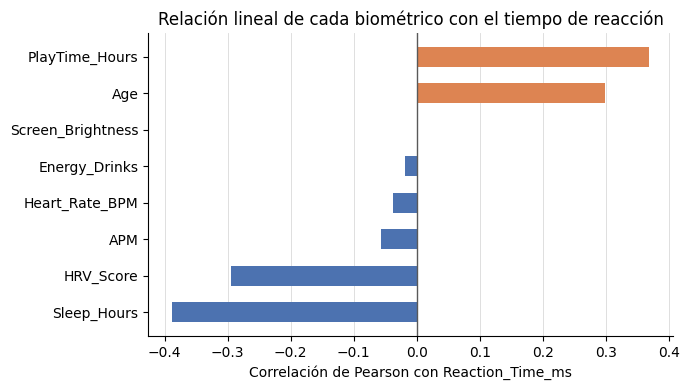


Match_Outcome (Win/Loss) vs Reaction_Time_ms -- ¿hay diferencia real?
                     mean        std   count
Match_Outcome                               
Loss           263.942624  19.149059  129844
Win            261.774430  18.976287  120156


In [2]:
print("Estadísticos descriptivos:")
display(df.describe().T)

num_cols_all = df.select_dtypes(include="number").columns.tolist()
corr = df[num_cols_all].corr()["Reaction_Time_ms"].drop("Reaction_Time_ms").sort_values()
print("\nCorrelación de cada variable numérica con Reaction_Time_ms:")
print(corr)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [ACCENT if v < 0 else ACCENT2 for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, height=0.55)
ax.axvline(0, color="#595959", linewidth=1)
ax.set_xlabel("Correlación de Pearson con Reaction_Time_ms")
ax.set_title("Relación lineal de cada biométrico con el tiempo de reacción")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("fig_correlaciones.png", dpi=110)
plt.show()

print("\nMatch_Outcome (Win/Loss) vs Reaction_Time_ms -- ¿hay diferencia real?")
print(df.groupby("Match_Outcome")["Reaction_Time_ms"].agg(["mean", "std", "count"]))

**Lectura del EDA:**

- `Sleep_Hours` (-0.39) y `PlayTime_Hours` (+0.37) son los predictores más fuertes; `Age` (+0.30) y `HRV_Score` (-0.29) también aportan. `Screen_Brightness` prácticamente no correlaciona (0.001).
- Ningún predictor por sí solo explica gran parte de la varianza (correlaciones moderadas), así que un **R² alrededor de 0.35–0.40** debe interpretarse como razonable para este fenómeno, no como un modelo pobre: el tiempo de reacción humano tiene un componente de ruido fisiológico que ninguna variable observada captura por completo.
- `Reaction_Time_ms` no muestra outliers imposibles (rango 175–355 ms, fisiológicamente plausible).
- La diferencia de medias entre `Win` y `Loss` es de apenas ~2 ms frente a una desviación estándar de ~19 ms: **`Match_Outcome` no aporta señal real** y, además, es *consecuencia* del partido (posible causalidad invertida), no una variable biométrica. Se descarta.
- `Player_ID` es un identificador único por fila: se descarta por no tener valor predictivo.
- `Screen_Brightness` y `HRV_Score` tienen nulos que se resolverán en el preprocesamiento, **después** de dividir train/test.

## 2. Preprocesamiento

### 2.1 Selección de variables, separación X/y y Hold-Out (70/30)

Regla de oro anti-fuga de datos: la partición train/test se hace **antes** de imputar, codificar o escalar. Cualquier estadístico (media, mediana, desviación estándar) usado para transformar los datos debe calcularse **solo** con el conjunto de entrenamiento.

In [3]:
target = "Reaction_Time_ms"
drop_cols = ["Player_ID", "Match_Outcome"]

X = df.drop(columns=drop_cols + [target])
y = df[target].copy()

numeric_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()
print("Variables numéricas   :", numeric_cols)
print("Variables categóricas :", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas (70/30)")

X_train = X_train.copy()
X_test = X_test.copy()

Variables numéricas   : ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks', 'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score']
Variables categóricas : ['Game_Genre', 'Blue_Light_Filter']

Train: 175,000 filas | Test: 75,000 filas (70/30)


### 2.2 Datos faltantes — Imputación

Se compara la media y la mediana de cada columna con nulos, calculadas **solo en train**, para decidir la estrategia con criterio y no por defecto:
- Si media ≈ mediana → distribución simétrica → **imputar con la media**.
- Si media y mediana difieren notoriamente → la variable está sesgada → **imputar con la mediana**, más robusta ante ese sesgo.

In [4]:
print("Nulos en TRAIN antes de imputar:")
print(X_train[numeric_cols].isnull().sum().loc[lambda s: s > 0])

mean_sb, median_sb = X_train["Screen_Brightness"].mean(), X_train["Screen_Brightness"].median()
mean_hrv, median_hrv = X_train["HRV_Score"].mean(), X_train["HRV_Score"].median()
print(f"\nScreen_Brightness -> media={mean_sb:.2f} | mediana={median_sb:.2f}  (similares -> MEDIA)")
print(f"HRV_Score         -> media={mean_hrv:.2f} | mediana={median_hrv:.2f}  (sesgo -> MEDIANA)")

imputer_mean = SimpleImputer(strategy="mean")
imputer_median = SimpleImputer(strategy="median")

X_train[["Screen_Brightness"]] = imputer_mean.fit_transform(X_train[["Screen_Brightness"]])
X_test[["Screen_Brightness"]] = imputer_mean.transform(X_test[["Screen_Brightness"]])

X_train[["HRV_Score"]] = imputer_median.fit_transform(X_train[["HRV_Score"]])
X_test[["HRV_Score"]] = imputer_median.transform(X_test[["HRV_Score"]])

print("\nNulos TRAIN después de imputar:", X_train[numeric_cols].isnull().sum().sum())
print("Nulos TEST  después de imputar:", X_test[numeric_cols].isnull().sum().sum())

Nulos en TRAIN antes de imputar:
Screen_Brightness    8818
HRV_Score            3457
dtype: int64

Screen_Brightness -> media=54.93 | mediana=54.80  (similares -> MEDIA)
HRV_Score         -> media=87.44 | mediana=89.17  (sesgo -> MEDIANA)

Nulos TRAIN después de imputar: 0
Nulos TEST  después de imputar: 0


### 2.3 Variables categóricas — One-Hot Encoding (Dummy Variables)

`Game_Genre` (4 categorías) y `Blue_Light_Filter` (2 categorías) son nominales (sin orden natural), así que se codifican con One-Hot Encoding. El codificador se **ajusta (fit) solo con train** y se aplica igual a test.

In [5]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[categorical_cols])
cat_names = ohe.get_feature_names_out(categorical_cols)
print("Columnas dummy generadas:", list(cat_names))

X_train_cat = pd.DataFrame(ohe.transform(X_train[categorical_cols]), columns=cat_names, index=X_train.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test[categorical_cols]), columns=cat_names, index=X_test.index)

X_train_full = pd.concat([X_train[numeric_cols].reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test_full = pd.concat([X_test[numeric_cols].reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

print(f"\nColumnas finales (numéricas + dummies): {X_train_full.shape[1]}")
X_train_full.head()

Columnas dummy generadas: ['Game_Genre_Battle Royale', 'Game_Genre_FPS', 'Game_Genre_Fighting', 'Game_Genre_MOBA', 'Blue_Light_Filter_No', 'Blue_Light_Filter_Yes']

Columnas finales (numéricas + dummies): 14


,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,APM,Heart_Rate_BPM,HRV_Score,Game_Genre_Battle Royale,Game_Genre_FPS,Game_Genre_Fighting,Game_Genre_MOBA,Blue_Light_Filter_No,Blue_Light_Filter_Yes
0,24,1.56,5.57,1,70.2,260,76,100.00,0.0,0.0,1.0,0.0,1.0,0.0
1,26,4.66,8.05,3,79.3,198,93,73.29,0.0,1.0,0.0,0.0,0.0,1.0
2,27,1.20,7.05,0,29.5,238,82,90.83,0.0,0.0,0.0,1.0,0.0,1.0
3,23,0.50,6.98,0,14.4,329,83,100.00,0.0,0.0,0.0,1.0,0.0,1.0
4,25,2.07,3.96,1,52.7,283,88,74.96,0.0,0.0,0.0,1.0,0.0,1.0


### 2.4 Escalado — StandardScaler

Obligatorio y ajustado (`fit`) **solo con train**. Es indispensable para KNN (algoritmo basado en distancia euclidiana: sin escalar, `APM` —en decenas/cientos— dominaría por completo a `Sleep_Hours` —de 0 a 11—). Para el Árbol y Random Forest no es matemáticamente necesario (los splits usan umbrales ordenados, no magnitudes), pero se aplica igual para mantener **un único pipeline consistente** entre los tres modelos y una comparación justa.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)
feature_names = list(X_train_full.columns)

y_train_arr = y_train.values
y_test_arr = y_test.values

print("Media por columna en TRAIN escalado (debe ser ~0):")
print(np.round(X_train_scaled.mean(axis=0), 3))
print("\nDesviación estándar por columna en TRAIN escalado (debe ser ~1):")
print(np.round(X_train_scaled.std(axis=0), 3))

Media por columna en TRAIN escalado (debe ser ~0):
[ 0. -0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0. -0.]

Desviación estándar por columna en TRAIN escalado (debe ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Árbol de Decisión aplicado en Regresion

### 3.1 Barrido de `max_depth` (1 a 30)

En vez de elegir las tres profundidades a ciegas, se barre un rango amplio y se grafica el error en train y test para **encontrar con evidencia** dónde ocurre el subajuste, el ajuste óptimo y el sobreajuste.

Profundidad con menor RMSE en TEST: 9


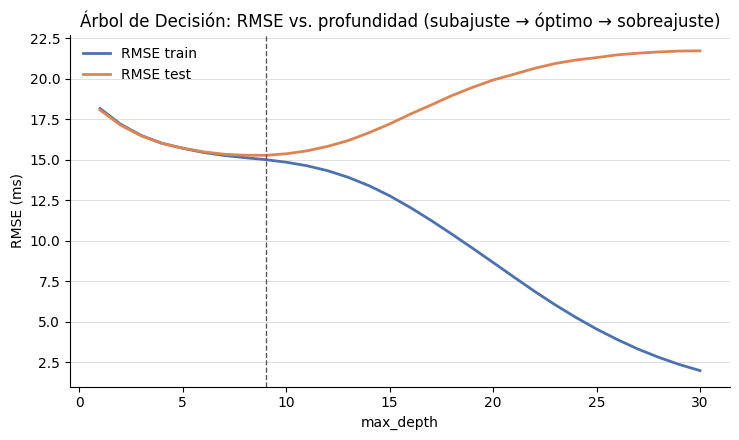

In [7]:
depths = list(range(1, 31))
rows = []
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train_scaled, y_train_arr)
    _, _, rmse_tr, r2_tr = metrics(y_train_arr, tree.predict(X_train_scaled))
    _, _, rmse_te, r2_te = metrics(y_test_arr, tree.predict(X_test_scaled))
    rows.append([d, rmse_tr, rmse_te, r2_tr, r2_te])

curve = pd.DataFrame(rows, columns=["max_depth", "RMSE_train", "RMSE_test", "R2_train", "R2_test"])
best_depth = int(curve.loc[curve["RMSE_test"].idxmin(), "max_depth"])
print(f"Profundidad con menor RMSE en TEST: {best_depth}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve["max_depth"], curve["RMSE_train"], color=ACCENT, linewidth=2, label="RMSE train")
ax.plot(curve["max_depth"], curve["RMSE_test"], color=ACCENT2, linewidth=2, label="RMSE test")
ax.axvline(best_depth, color="#595959", linestyle="--", linewidth=1)
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE (ms)")
ax.set_title("Árbol de Decisión: RMSE vs. profundidad (subajuste → óptimo → sobreajuste)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("fig_arbol_barrido.png", dpi=110)
plt.show()

### 3.2 Los tres árboles exigidos por la entrega

- **Subajuste (poda superficial):** `max_depth=2`, un árbol demasiado simple para capturar el fenómeno.
- **Ajuste óptimo:** la profundidad hallada en el barrido anterior (menor RMSE en test).
- **Sobreajuste (poda exagerada / sin poda):** `max_depth=None`, el árbol crece hasta pureza total y memoriza el train.

In [8]:
configs = {
    "Subajuste (max_depth=2)": 2,
    f"Ajuste óptimo (max_depth={best_depth})": best_depth,
    "Sobreajuste (max_depth=None, sin poda)": None,
}

arbol_rows = []
arboles_entrenados = {}
for label, d in configs.items():
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train_scaled, y_train_arr)
    arboles_entrenados[label] = tree
    mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train_arr, tree.predict(X_train_scaled))
    mae_te, mse_te, rmse_te, r2_te = metrics(y_test_arr, tree.predict(X_test_scaled))
    arbol_rows.append([label, tree.get_depth(), tree.get_n_leaves(),
                        mae_tr, mse_tr, rmse_tr, r2_tr, mae_te, mse_te, rmse_te, r2_te])

arbol_df = pd.DataFrame(arbol_rows, columns=[
    "Configuración", "Profundidad real", "Hojas",
    "MAE_train", "MSE_train", "RMSE_train", "R2_train",
    "MAE_test", "MSE_test", "RMSE_test", "R2_test"
])
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(arbol_df.round(3))

# ¿Cuál quedó como variable más importante / nodo raíz? (para la sustentación)
tree_optimo = arboles_entrenados[f"Ajuste óptimo (max_depth={best_depth})"]
importancias = pd.Series(tree_optimo.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nImportancia de variables (árbol óptimo) -- la más alta es candidata a nodo raíz:")
print(importancias.head(6))

,Configuración,Profundidad real,Hojas,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test
0,Subajuste (max_depth=2),2,4,13.719,295.710,17.196,0.192,13.666,293.832,17.142,0.188
1,Ajuste óptimo (max_depth=9),9,511,11.967,225.303,15.010,0.384,12.176,233.382,15.277,0.355
2,"Sobreajuste (max_depth=None, sin poda)",53,174904,0.000,0.000,0.000,1.000,17.417,477.781,21.858,-0.321



Importancia de variables (árbol óptimo) -- la más alta es candidata a nodo raíz:
Sleep_Hours          0.398631
PlayTime_Hours       0.361366
Age                  0.228472
Energy_Drinks        0.003161
Screen_Brightness    0.002595
APM                  0.002077
dtype: float64


**Interpretación (argumento para la sustentación):**

- Con `max_depth=2` el error de train y de test son casi idénticos, pero **ambos son altos**: es la firma del **subajuste** (el modelo es demasiado simple, no tiene capacidad para capturar el patrón).
- En la profundidad óptima, el error de test alcanza su mínimo y la brecha train-test sigue siendo pequeña: el modelo generaliza.
- Sin poda (`max_depth=None`), el árbol crece hasta memorizar cada instancia de entrenamiento: **R² de train = 1.0** (ajuste perfecto e irreal) pero el **R² de test se vuelve negativo** (peor que predecir siempre el promedio). Es la firma inequívoca del **sobreajuste**: el árbol aprendió ruido específico del conjunto de entrenamiento, no el patrón general.
- La variable con mayor importancia (la de mayor ganancia de información acumulada) es la que el propio `DecisionTreeRegressor` de sklearn coloca en las divisiones más altas del árbol — de ahí se lee el nodo raíz sin necesidad de calcular entropía a mano.

## 4. Random Forest Regressor

Random Forest entrena muchos árboles (con submuestras de filas y de columnas distintas para cada uno) y promedia sus predicciones (bagging). Se comparan **3 cantidades de árboles** con cronómetro, y se agrega una referencia sin poda para ver si el ensamble por sí solo controla el sobreajuste de un árbol individual.

n_estimators= 10 | tiempo entrenamiento=  3.27s | RMSE_test=15.189 | R2_test=0.3623


n_estimators= 50 | tiempo entrenamiento= 16.91s | RMSE_test=15.103 | R2_test=0.3695


n_estimators=150 | tiempo entrenamiento= 51.74s | RMSE_test=15.094 | R2_test=0.3702


,n_estimators,fit_time_s,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,ganancia_R2_marginal,costo_tiempo_marginal_s
0,10,3.2749,11.2068,14.0318,0.4619,12.1148,15.1892,0.3623,NaN,NaN
1,50,16.9135,11.1477,13.9416,0.4688,12.0474,15.1028,0.3695,0.0072,13.6387
2,150,51.7410,11.1353,13.9231,0.4703,12.0386,15.0944,0.3702,0.0007,34.8275


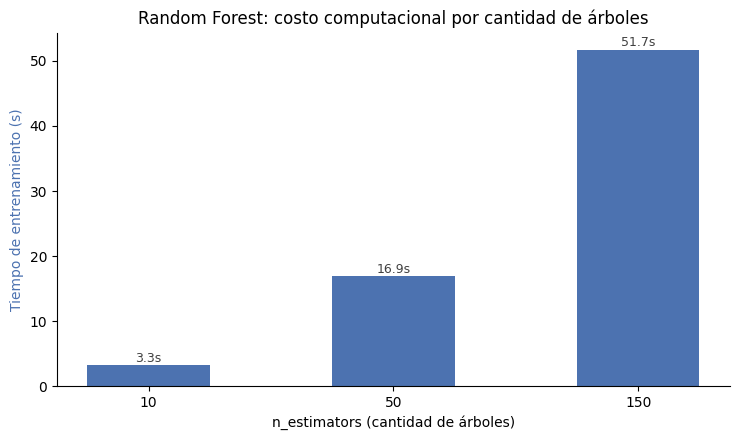


Referencia RF sin poda (150 árboles, max_depth=None): tiempo=109.7s
TRAIN -> R2=0.9111 | TEST -> R2=0.3530  (comparar con el árbol único sin poda: R2_test negativo)


In [9]:
n_estimators_list = [10, 50, 150]
rf_rows = []
for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    t0 = time.time(); rf.fit(X_train_scaled, y_train_arr); fit_time = time.time() - t0
    mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train_arr, rf.predict(X_train_scaled))
    mae_te, mse_te, rmse_te, r2_te = metrics(y_test_arr, rf.predict(X_test_scaled))
    rf_rows.append([n, fit_time, mae_tr, rmse_tr, r2_tr, mae_te, rmse_te, r2_te])
    print(f"n_estimators={n:>3} | tiempo entrenamiento={fit_time:6.2f}s | RMSE_test={rmse_te:.3f} | R2_test={r2_te:.4f}")

rf_df = pd.DataFrame(rf_rows, columns=["n_estimators", "fit_time_s", "MAE_train", "RMSE_train", "R2_train", "MAE_test", "RMSE_test", "R2_test"])
rf_df["ganancia_R2_marginal"] = rf_df["R2_test"].diff()
rf_df["costo_tiempo_marginal_s"] = rf_df["fit_time_s"].diff()
display(rf_df.round(4))

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.bar([str(n) for n in rf_df["n_estimators"]], rf_df["fit_time_s"], color=ACCENT, width=0.5)
ax1.set_ylabel("Tiempo de entrenamiento (s)", color=ACCENT)
ax1.set_xlabel("n_estimators (cantidad de árboles)")
ax1.set_title("Random Forest: costo computacional por cantidad de árboles")
ax1.spines[["top", "right"]].set_visible(False)
for i, v in enumerate(rf_df["fit_time_s"]):
    ax1.text(i, v + 0.5, f"{v:.1f}s", ha="center", color="#404040", fontsize=9)
plt.tight_layout()
plt.savefig("fig_rf_tiempos.png", dpi=110)
plt.show()

# Referencia: RF con arboles sin poda (para comparar contra el arbol unico sobreajustado)
rf_full = RandomForestRegressor(n_estimators=150, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time(); rf_full.fit(X_train_scaled, y_train_arr); fit_time_full = time.time() - t0
mae_tr, mse_tr, rmse_tr, r2_tr = metrics(y_train_arr, rf_full.predict(X_train_scaled))
mae_te, mse_te, rmse_te, r2_te = metrics(y_test_arr, rf_full.predict(X_test_scaled))
print(f"\nReferencia RF sin poda (150 árboles, max_depth=None): tiempo={fit_time_full:.1f}s")
print(f"TRAIN -> R2={r2_tr:.4f} | TEST -> R2={r2_te:.4f}  (comparar con el árbol único sin poda: R2_test negativo)")

**Interpretación (costo computacional vs. ganancia de métrica):**

- Pasar de 10 a 50 árboles cuesta un salto de tiempo considerable a cambio de una mejora de R² todavía visible.
- Pasar de 50 a 150 árboles casi **triplica el tiempo de entrenamiento** para una ganancia de R² marginal casi nula: son **rendimientos decrecientes**. Con 50 árboles ya se captura casi toda la mejora posible; los 100 árboles adicionales son, en la práctica, costo computacional sin beneficio proporcional.
- La referencia sin poda muestra que, aunque cada árbol individual del bosque se sobreajuste (por eso el R² de train sigue siendo muy alto), **promediar muchos árboles distintos reduce drásticamente el sobreajuste** frente a un único árbol sin poda: el Random Forest sin poda todavía generaliza razonablemente en test, mientras que el árbol único sin poda tenía R² de test negativo. Esa es la idea central del *bagging*: cada árbol individual tiene alta varianza, pero el promedio de árboles poco correlacionados entre sí reduce esa varianza sin aumentar mucho el sesgo.

## 5. KNN Aplicado a Regresion

### 5.1 Búsqueda sistemática de K

El escalado ya aplicado (sección 2.4) es lo que hace válida la distancia euclidiana aquí. Para acelerar el barrido de K se evalúa sobre una **muestra aleatoria de 15,000 filas de test** (no el test completo); una vez elegido K, la evaluación final sí usa el test completo.

K con RMSE mínimo (muestra): 50
K elegido por criterio de codo (dentro de 0.5% del mínimo, el más chico -> menor costo): 30


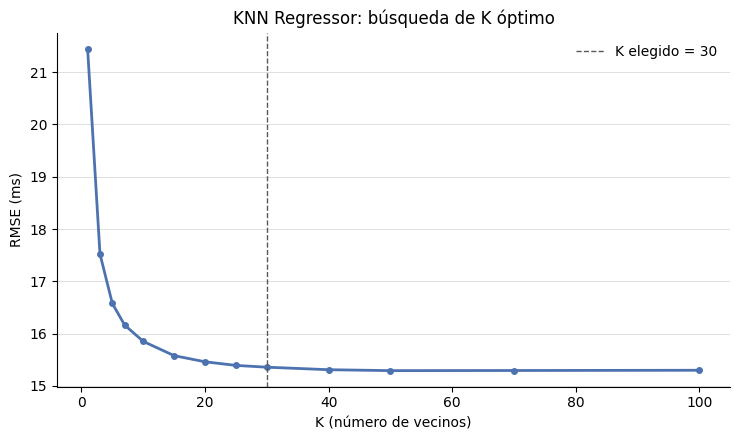

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test_scaled), size=15000, replace=False)
X_test_sample = X_test_scaled[sample_idx]
y_test_sample = y_test_arr[sample_idx]

k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50, 70, 100]
knn_rows = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights="uniform", n_jobs=-1)
    knn.fit(X_train_scaled, y_train_arr)
    pred = knn.predict(X_test_sample)
    _, _, rmse, r2 = metrics(y_test_sample, pred)
    knn_rows.append([k, rmse, r2])

knn_curve = pd.DataFrame(knn_rows, columns=["K", "RMSE_test", "R2_test"])
min_rmse = knn_curve["RMSE_test"].min()
k_elbow = int(knn_curve.loc[knn_curve["RMSE_test"] <= min_rmse * 1.005, "K"].min())
print(f"K con RMSE mínimo (muestra): {int(knn_curve.loc[knn_curve['RMSE_test'].idxmin(),'K'])}")
print(f"K elegido por criterio de codo (dentro de 0.5% del mínimo, el más chico -> menor costo): {k_elbow}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(knn_curve["K"], knn_curve["RMSE_test"], color=ACCENT, linewidth=2, marker="o", markersize=4)
ax.axvline(k_elbow, color="#595959", linestyle="--", linewidth=1, label=f"K elegido = {k_elbow}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("RMSE (ms)")
ax.set_title("KNN Regressor: búsqueda de K óptimo")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("fig_knn_busqueda_k.png", dpi=110)
plt.show()

k_final = k_elbow

### 5.2 Pesos uniformes vs. distancia (evaluación final con el test completo)

Con pesos uniformes, los K vecinos votan por igual. Con pesos por distancia, un vecino más cercano pesa más que uno lejano dentro del mismo grupo de K. No se reporta "error de entrenamiento" para KNN evaluando sobre el propio train, porque cada instancia se encontraría a sí misma como vecino a distancia 0, inflando artificialmente el ajuste. Por eso un modelo basado en instancia se evalúa sobre test.

In [11]:
knn_final_rows = []
for w in ["uniform", "distance"]:
    knn = KNeighborsRegressor(n_neighbors=k_final, weights=w, n_jobs=-1)
    t0 = time.time(); knn.fit(X_train_scaled, y_train_arr)
    pred_test = knn.predict(X_test_scaled)
    t1 = time.time()
    mae, mse, rmse, r2 = metrics(y_test_arr, pred_test)
    knn_final_rows.append([w, k_final, t1 - t0, mae, mse, rmse, r2])

knn_final_df = pd.DataFrame(knn_final_rows, columns=["weights", "K", "tiempo_s", "MAE_test", "MSE_test", "RMSE_test", "R2_test"])
display(knn_final_df.round(4))

,weights,K,tiempo_s,MAE_test,MSE_test,RMSE_test,R2_test
0,uniform,30,31.6836,12.2724,236.9893,15.3945,0.3449
1,distance,30,31.7739,12.2715,236.9379,15.3928,0.3451


**Interpretación:** con K ya en un valor moderado (elegido por el codo) la diferencia entre pesos uniformes y por distancia es mínima: ambos esquemas terminan promediando información muy similar porque, dentro de un radio ya "razonable" de K vecinos, la mayoría están a distancias comparables tras el escalado. La ventaja de los pesos por distancia se nota más con K grande (donde vecinos lejanos, poco relevantes, podrían diluir la predicción si votaran igual) — aquí, al haber elegido K por el criterio de codo, ese efecto ya está mitigado de entrada.

## 6. Comparación final de los tres algoritmos

,Modelo,MAE_test,MSE_test,RMSE_test,R2_test
0,Árbol de Decisión (óptimo),12.176,233.382,15.277,0.355
1,Random Forest (150 árboles),12.039,227.840,15.094,0.370
2,"KNN (K=30, distance)",12.271,236.938,15.393,0.345


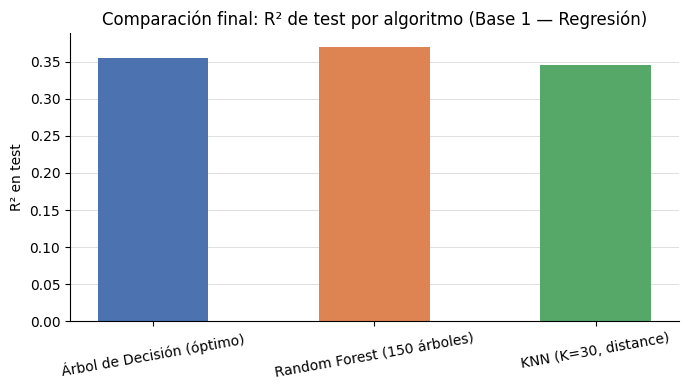

In [12]:
mejor_arbol = arbol_df.loc[arbol_df["Configuración"].str.contains("óptimo")].iloc[0]
mejor_rf = rf_df.loc[rf_df["R2_test"].idxmax()]
mejor_knn = knn_final_df.loc[knn_final_df["R2_test"].idxmax()]

resumen_final = pd.DataFrame([
    ["Árbol de Decisión (óptimo)", mejor_arbol["MAE_test"], mejor_arbol["MSE_test"], mejor_arbol["RMSE_test"], mejor_arbol["R2_test"]],
    [f"Random Forest ({int(mejor_rf['n_estimators'])} árboles)", mejor_rf["MAE_test"], mejor_rf["RMSE_test"]**2, mejor_rf["RMSE_test"], mejor_rf["R2_test"]],
    [f"KNN (K={k_final}, {mejor_knn['weights']})", mejor_knn["MAE_test"], mejor_knn["MSE_test"], mejor_knn["RMSE_test"], mejor_knn["R2_test"]],
], columns=["Modelo", "MAE_test", "MSE_test", "RMSE_test", "R2_test"])

display(resumen_final.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumen_final["Modelo"], resumen_final["R2_test"], color=[ACCENT, ACCENT2, "#55A868"], width=0.5)
ax.set_ylabel("R² en test")
ax.set_title("Comparación final: R² de test por algoritmo (Base 1 — Regresión)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("fig_comparacion_final.png", dpi=110)
plt.show()

## 7. Puntos clave para la sustentación

1. **Orden anti-fuga:** Hold-Out 70/30 primero, imputación/One-Hot/escalado ajustados solo con train, después transform en test.
2. **Decisiones justificadas, no por defecto:** `Player_ID` y `Match_Outcome` se descartan con argumento (identificador sin valor; resultado del partido, no variable biométrica, con diferencia de medias insignificante). La imputación se decide columna por columna comparando media vs. mediana.
3. **El techo de R² (~0.35–0.40) es del fenómeno, no del modelo:** las correlaciones individuales son moderadas, así que ningún algoritmo va a superar mucho ese techo salvo que sobreajuste (y ahí el R² de test se degrada).
4. **Árbol de Decisión:** se lee el subajuste/óptimo/sobreajuste directamente del cruce de las curvas de RMSE train vs. test; el sobreajuste se reconoce por R² train = 1.0 con R² test negativo.
5. **Random Forest:** más árboles no es gratis — hay rendimientos decrecientes de R² frente al tiempo de entrenamiento; el bagging reduce el sobreajuste de árboles individuales al promediarlos, aunque cada árbol por separado esté sobreajustado.
6. **KNN:** el escalado es la precondición que hace válida la distancia; el K se elige con un criterio explícito (codo, no solo "el mínimo"); los pesos por distancia aportan más cuando K es grande.
7. **Random Forest también se debe presentar en el ejercicio de clasificación (Base 2)** — la exigencia del profesor es aplicar el mismo algoritmo en ambos frentes.